In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import f as f_dist
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import random
import time

Using device: cuda


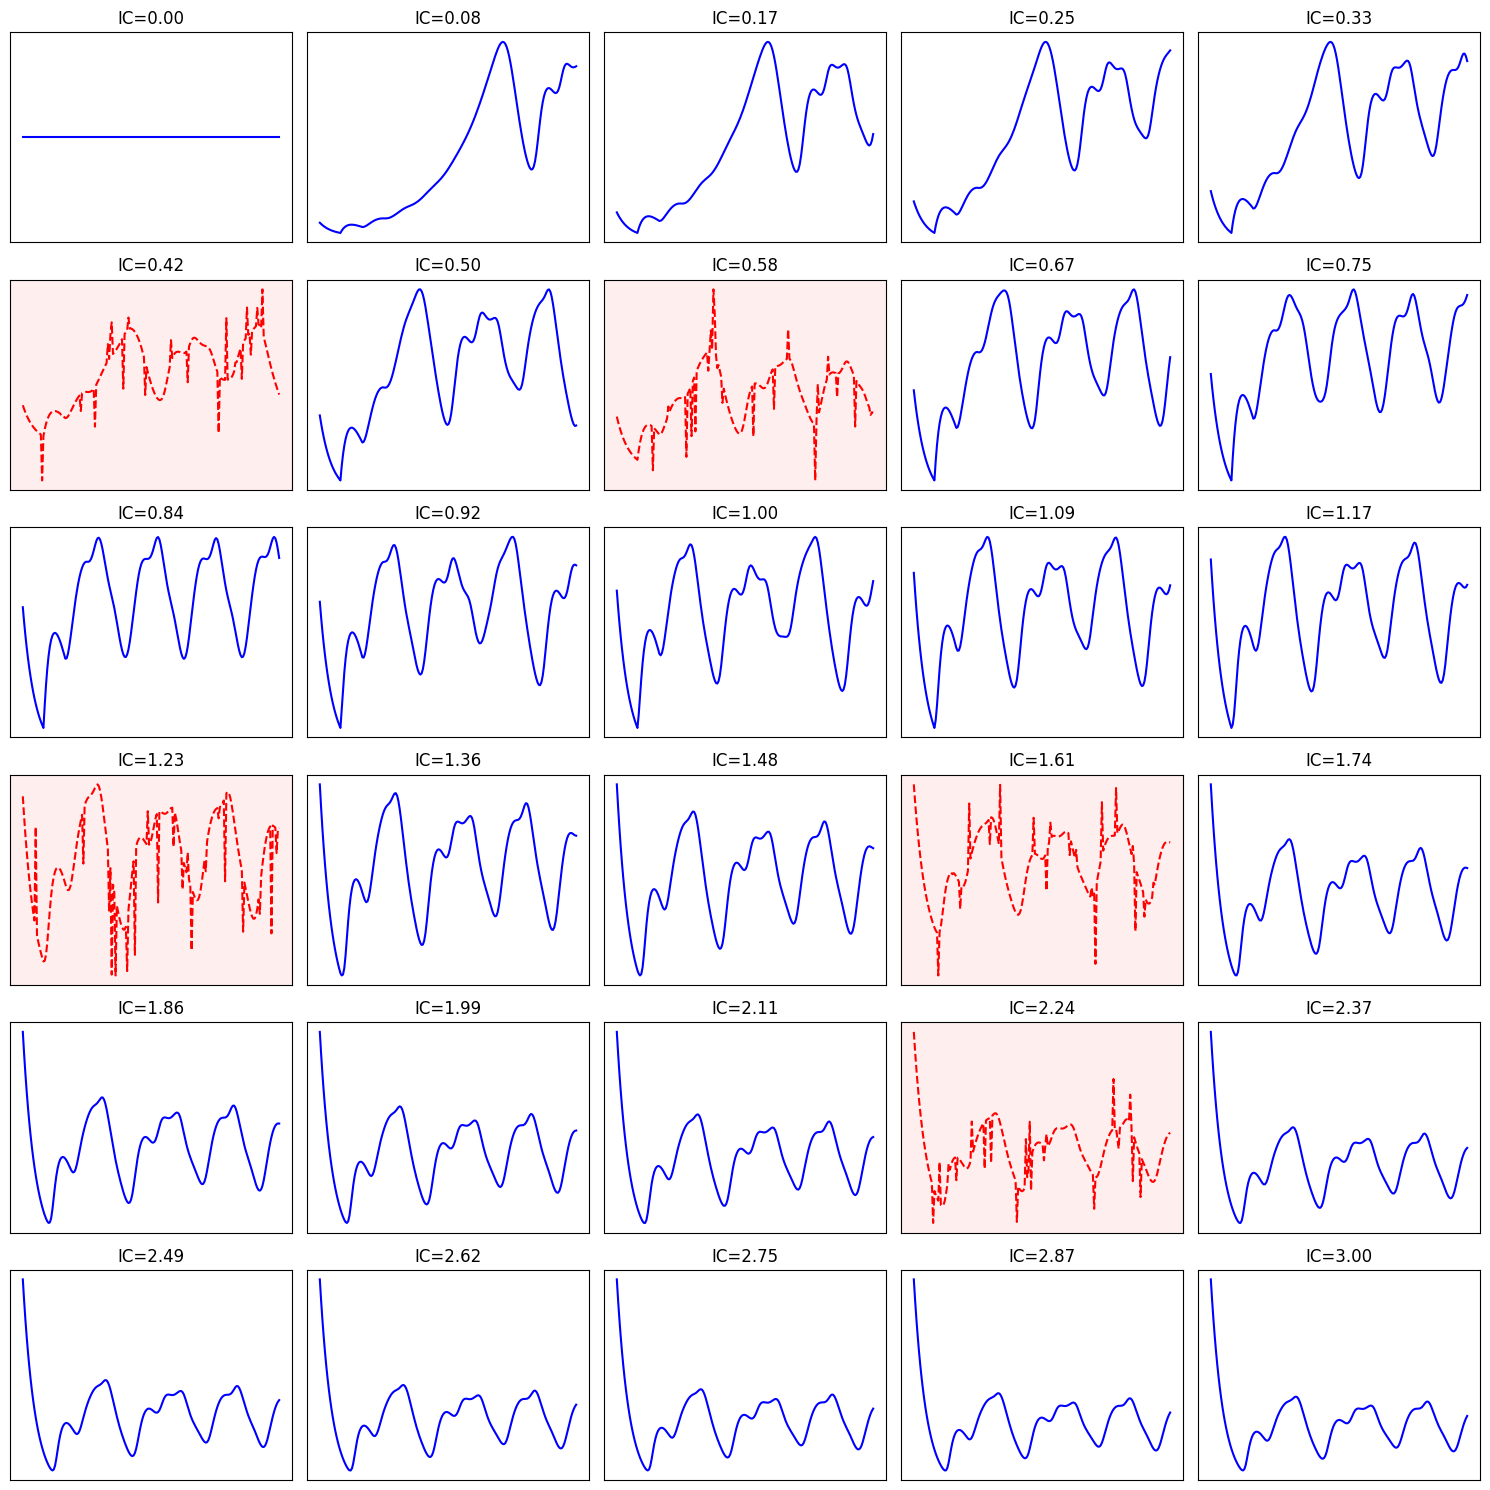

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import time
import torch
import numpy as np
import random

# --- 1. Fix Python, NumPy, and random seeds ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# --- 2. Force deterministic behavior for cuDNN ---
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Use GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=0.8):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x
# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    """
    Insert anomalies into a time series.
    anomaly_rate: fraction of points that are anomalous
    anomaly_scale: magnitude of anomalies
    """
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)

    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 0.8
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data (with anomalies on 5 sequences) ---
X_list, y_list = [], []
rng = np.random.default_rng()  # independent generator (no fixed seed)
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)  # insert anomalies
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

import math

# Number of rows and columns for subplot grid
n_traj = len(y_list)
n_cols = 5  # you can change this
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols*3, n_rows*2.5))

for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([])
    plt.yticks([])
    if i in anomalous_indices:
        plt.gca().set_facecolor("#ffeeee")  # light red background for anomalies

plt.tight_layout()
plt.show()




# --- Generate test data ---
x_test = mackey_glass(t_max=200, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0).to(device)

# Split into train and validation (36 train, 4 val)
val_split = 1
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

In [11]:
# --- GRU Model ---
class GRUNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=3):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.linear(out).squeeze(-1)
        return out

In [12]:
model = GRUNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# --- Early stopping params ---
best_val_loss = float('inf')
patience = 40
patience_counter = 0
best_model_state = None
# --- Train with validation tracking ---
train_losses = []
val_losses = []
start_time = time.time()
epochs = 200

# --- Train the model ---
epochs = 200
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for xb_val, yb_val in val_loader:
            xb_val, yb_val = xb_val.to(device), yb_val.to(device)
            val_output = model(xb_val)
            val_loss += criterion(val_output, yb_val).item()
        val_loss /= len(val_loader)

    print(f"Epoch {epoch:03d}: Train Loss = {total_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Check early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 000: Train Loss = 3.3468, Val Loss = 0.1370
Epoch 001: Train Loss = 1.2296, Val Loss = 0.0860
Epoch 002: Train Loss = 0.9876, Val Loss = 0.0936
Epoch 003: Train Loss = 0.9868, Val Loss = 0.0853
Epoch 004: Train Loss = 0.9220, Val Loss = 0.0858
Epoch 005: Train Loss = 0.8961, Val Loss = 0.0821
Epoch 006: Train Loss = 0.9007, Val Loss = 0.0772
Epoch 007: Train Loss = 0.8787, Val Loss = 0.0686
Epoch 008: Train Loss = 0.8699, Val Loss = 0.0606
Epoch 009: Train Loss = 0.8866, Val Loss = 0.0644
Epoch 010: Train Loss = 0.7850, Val Loss = 0.0500
Epoch 011: Train Loss = 0.8492, Val Loss = 0.0507
Epoch 012: Train Loss = 0.8114, Val Loss = 0.0452
Epoch 013: Train Loss = 0.7350, Val Loss = 0.0443
Epoch 014: Train Loss = 0.7724, Val Loss = 0.0439
Epoch 015: Train Loss = 0.7188, Val Loss = 0.0554
Epoch 016: Train Loss = 0.7047, Val Loss = 0.0513
Epoch 017: Train Loss = 0.6619, Val Loss = 0.0540
Epoch 018: Train Loss = 0.6363, Val Loss = 0.0572
Epoch 019: Train Loss = 0.6246, Val Loss = 0.0521


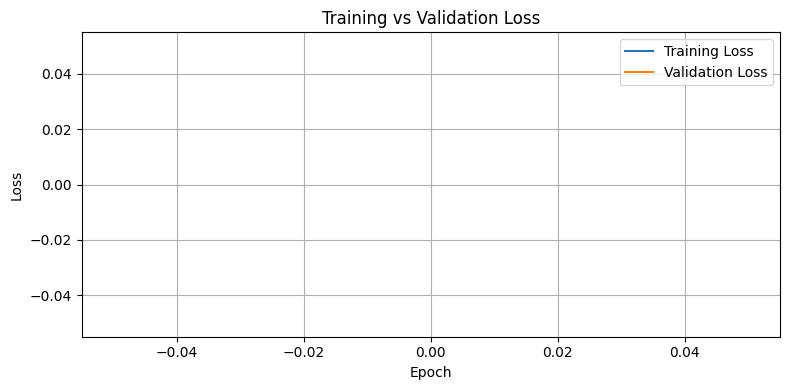


Test RMSE: 0.1581
Test R²:   0.6643


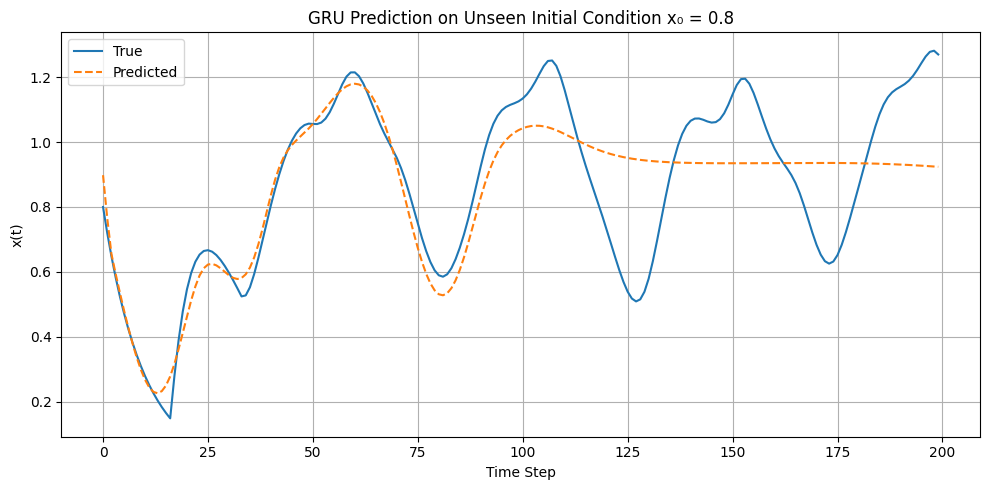

F-statistic: 194.9409
P-value:     1.1102e-16
Total Runtime: 0.00 seconds


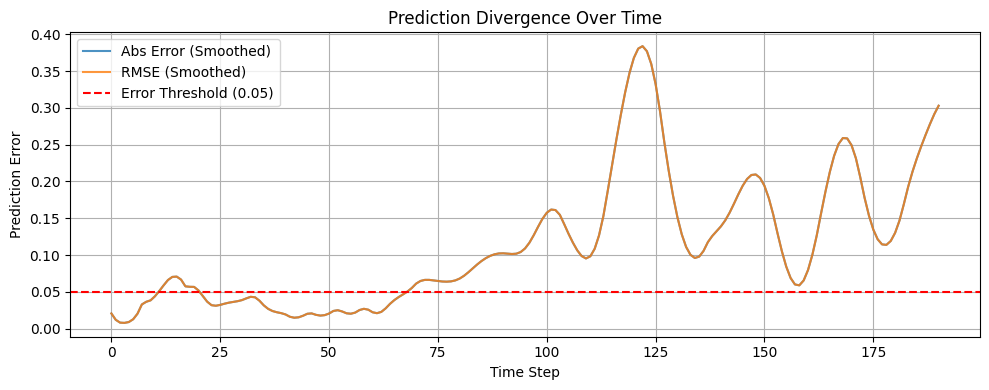

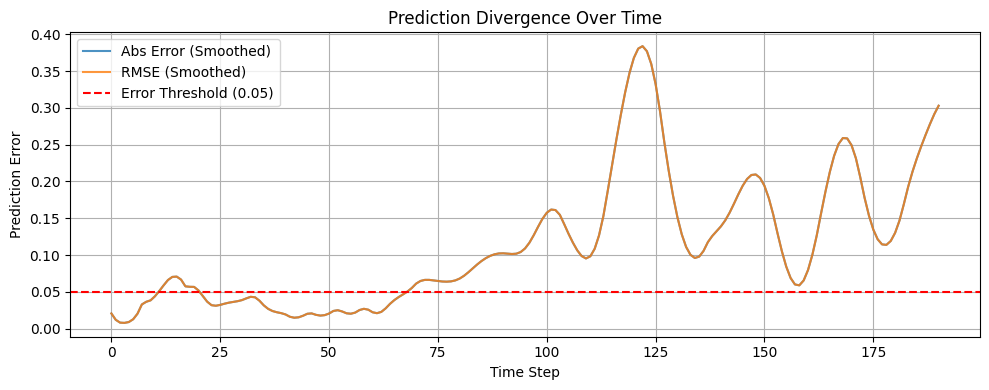

Prediction horizon at threshold 0.05: 11 steps
Total runtime: 0.00 seconds


In [13]:
# --- Plot Training vs Validation Loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Load best model ---
start_time = time.time()
# --- Predict on test IC ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")
end_time = time.time()
# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"GRU Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- F-statistic and p-value ---
n = len(y_test)
k = X_test.shape[1]  # number of predictors = 2
F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f_dist.cdf(F_stat, k, n - k - 1)

print(f"F-statistic: {F_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

print(f"Total Runtime: {end_time - start_time:.2f} seconds")

import numpy as np
import matplotlib.pyplot as plt

# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold)
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")


print(f"Total runtime: {end_time - start_time:.2f} seconds")

In [14]:
from scipy.stats import pearsonr, spearmanr

def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_test, pred_test)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

Pearson correlation: 0.8167
Spearman correlation: 0.5918


Spectral cosine similarity: 0.9415


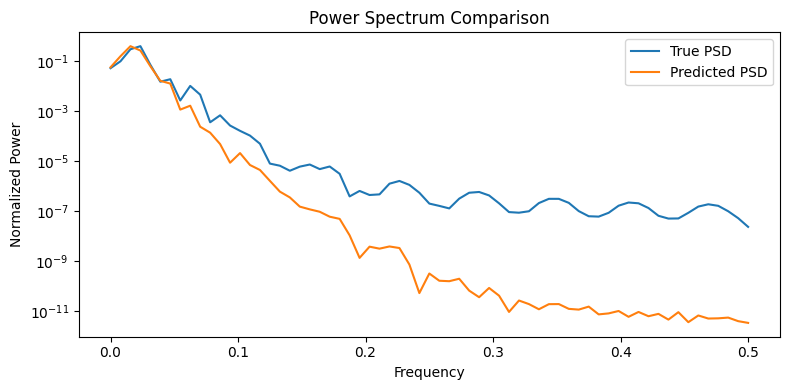

In [15]:
from scipy.signal import welch
from numpy.linalg import norm

def spectral_similarity(y_true, y_pred, fs=1.0):
    # Welch’s method for power spectral density (PSD)
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=128)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=128)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_test, pred_test)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import torch
from torch.utils.data import DataLoader

# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Expanded hyperparameter search space
hidden_sizes = [32, 64, 128, 256]
num_layers_list = [1, 2, 3]
learning_rates = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
batch_sizes = [4, 8, 16]
dropouts = [0.0, 0.2, 0.4]

# Redefine GRU model class to accept dropout
class GRUNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.0):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.linear(out).squeeze(-1)
        return out

# Grid search
best_model = None
best_loss = float("inf")
best_config = None

for h in hidden_sizes:
    for l in num_layers_list:
        for lr in learning_rates:
            for bs in batch_sizes:
                for do in dropouts:
                    print(f"\nTraining: hidden={h}, layers={l}, lr={lr}, batch={bs}, dropout={do}")

                    # Define model, optimizer, dataloader
                    model = GRUNet(hidden_size=h, num_layers=l, dropout=do).to(device)
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)

                    # Train for a few quick epochs
                    for epoch in range(15):
                        model.train()
                        for xb, yb in train_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            optimizer.zero_grad()
                            output = model(xb)
                            loss = criterion(output, yb)
                            loss.backward()
                            optimizer.step()

                    # Evaluate on validation set
                    model.eval()
                    val_loss = 0
                    with torch.no_grad():
                        for xb, yb in val_loader:
                            xb, yb = xb.to(device), yb.to(device)
                            val_loss += criterion(model(xb), yb).item()
                    val_loss /= len(val_loader)
                    print(f"Val Loss: {val_loss:.5f}")

                    # Save best model
                    if val_loss < best_loss:
                        best_loss = val_loss
                        best_model = model
                        best_config = (h, l, lr, bs, do)

print(f"\n✅ Best Config: Hidden={best_config[0]}, Layers={best_config[1]}, "
      f"LR={best_config[2]}, Batch={best_config[3]}, Dropout={best_config[4]} "
      f"→ Val Loss={best_loss:.5f}")

Using device: cuda

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.0
Val Loss: 0.06591

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.2
Val Loss: 0.06636

Training: hidden=32, layers=1, lr=0.01, batch=4, dropout=0.4
Val Loss: 0.16769

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.0
Val Loss: 0.04434

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.2
Val Loss: 0.06487

Training: hidden=32, layers=1, lr=0.01, batch=8, dropout=0.4
Val Loss: 0.04206

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.0
Val Loss: 0.09152

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.2
Val Loss: 0.08241

Training: hidden=32, layers=1, lr=0.01, batch=16, dropout=0.4
Val Loss: 0.07295

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.0
Val Loss: 0.04211

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.2
Val Loss: 0.04913

Training: hidden=32, layers=1, lr=0.005, batch=4, dropout=0.4
Val Loss: 0.04979

Training: hidd